In [ ]:
# Importar Librerías
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cv2
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Cargar Dataset (Fashion-MNIST)
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
# Preprocesamiento: Normalizar (escalamiento de pixeles)
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
# Definir la Arquitectura Densa con modelo secuencial
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Matriz de 28x28 a vector plano de 784 neuronas
    keras.layers.Dense(128, activation='relu'), # Capa aprendizaje de patrones complejos
    keras.layers.Dense(10, activation='softmax') # Capa salida con 10 neuronas por categoría y act. softmax
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compilar Modelo mediante optimizador Adam
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Entrenar denfiniendo las 'epoches'.
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8158 - loss: 0.5235 - val_accuracy: 0.8391 - val_loss: 0.4405
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8605 - loss: 0.3888 - val_accuracy: 0.8518 - val_loss: 0.4016
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8728 - loss: 0.3471 - val_accuracy: 0.8730 - val_loss: 0.3606
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8814 - loss: 0.3217 - val_accuracy: 0.8730 - val_loss: 0.3562
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8876 - loss: 0.3027 - val_accuracy: 0.8754 - val_loss: 0.3338
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8923 - loss: 0.2875 - val_accuracy: 0.8840 - val_loss: 0.3279
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8976 - loss: 0.2749 - val_accuracy: 0.8734 - val_loss: 0.3539
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9025 - loss: 0.2619 -

In [ ]:
# Evaluar el rendimiento
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nPrecisión final en test:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8769 - loss: 0.3623

Precisión final en test: 0.8769000172615051


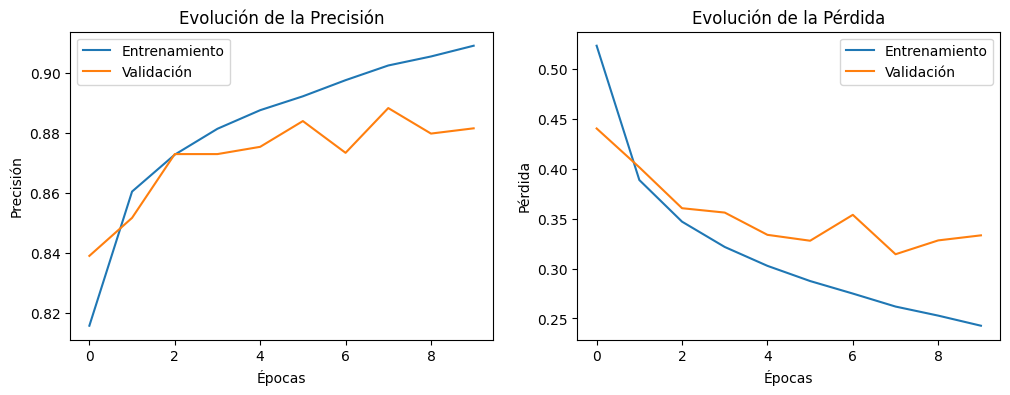

In [ ]:
 # Visualizar las curvas de entrenamiento
def plot_history(history):
    # Gráfico de Precisión (Accuracy)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Evolución de la Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Evolución de la Pérdida')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


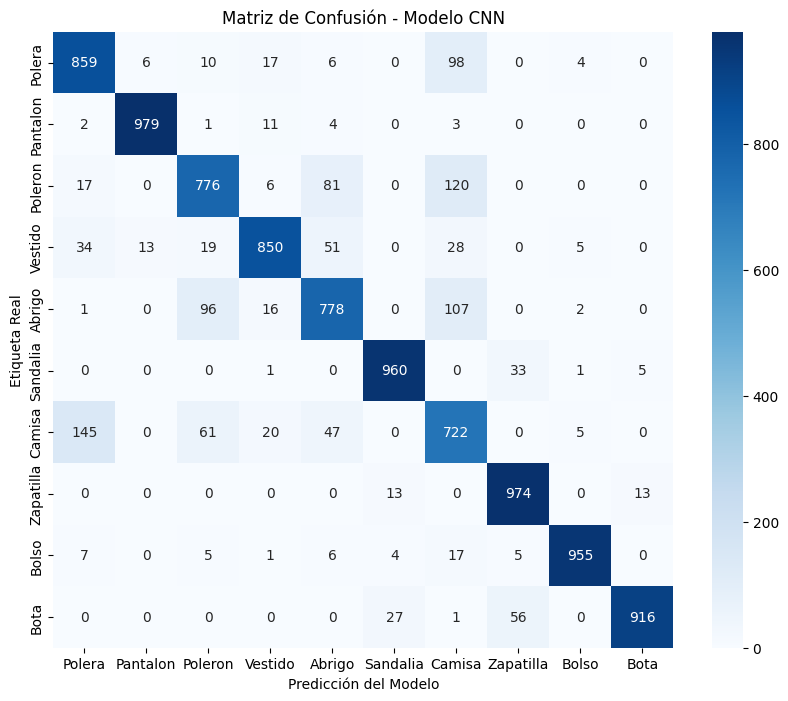


Reporte de Clasificación (CNN):
              precision    recall  f1-score   support

      Polera       0.81      0.86      0.83      1000
    Pantalon       0.98      0.98      0.98      1000
     Poleron       0.80      0.78      0.79      1000
     Vestido       0.92      0.85      0.88      1000
      Abrigo       0.80      0.78      0.79      1000
    Sandalia       0.96      0.96      0.96      1000
      Camisa       0.66      0.72      0.69      1000
   Zapatilla       0.91      0.97      0.94      1000
       Bolso       0.98      0.95      0.97      1000
        Bota       0.98      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# Matriz de Confusión y Reporte de Clasificación
# Generar predicciones en el conjunto de prueba
predicciones_prob = model.predict(test_images)
predicciones_clases = np.argmax(predicciones_prob, axis=1)

# Nombres de las categorías de Fashion-MNIST
categorias = ['Polera', 'Pantalon', 'Poleron', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

# Calcular la Matriz de Confusión
cm = confusion_matrix(test_labels, predicciones_clases)

# Visualizar la Matriz con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.title('Matriz de Confusión - Modelo CNN')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

# Imprimir el Reporte de Clasificación (Precision, Recall, F1-Score)
print("\nReporte de Clasificación (CNN):")
print(classification_report(test_labels, predicciones_clases, target_names=categorias))

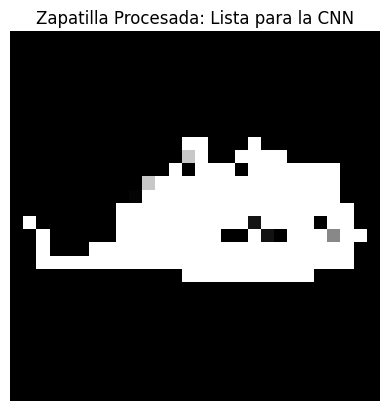

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

 La red predice que es: Zapatilla


In [ ]:
# Leer imagen real en escala de grises
img = cv2.imread('zapatilla_real.jpg', cv2.IMREAD_GRAYSCALE)

# Se quita el fondo de forma mejorada
edges = np.concatenate([img[0:10, :].flatten(), img[-10:, :].flatten(),
                        img[:, 0:10].flatten(), img[:, -10:].flatten()])
bg_color = np.median(edges)
diff = np.abs(img.astype(np.int16) - bg_color).astype(np.uint8)

# Aplicar Umbral (Threshold) para binarizar
_, img_thresh = cv2.threshold(diff, 40, 255, cv2.THRESH_BINARY)

# Quitar ruido y usar kernel para rellenar los agujeros negros dentro de la zapatilla blanca
kernel = np.ones((5,5), np.uint8)
img_cleaned = cv2.morphologyEx(img_thresh, cv2.MORPH_CLOSE, kernel) # Cierra agujeros
img_cleaned = cv2.morphologyEx(img_cleaned, cv2.MORPH_OPEN, kernel)  # Elimina ruido externo

# Redimensionar al formato de la CNN
img_resized = cv2.resize(img_cleaned, (28, 28))

# Visualizar la silueta final
plt.imshow(img_resized, cmap='gray')
plt.title("Zapatilla Procesada: Lista para la CNN")
plt.axis('off')
plt.show()

# Preparar tensor y Predecir
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediccion = model.predict(img_array)
clase_index = np.argmax(prediccion)
print(f"\n La red predice que es: {categorias[clase_index]}")